load df:

In [41]:
import pandas as pd
from py_scripts.music_utils import draw_piano_roll

#load data from TSV
df = pd.read_csv('tsv/test_bach_burg.tsv', delimiter='\t')

# Extract measure offsets for measure lines
# For measure 1, use 0.0; for other measures, use the minimum onset time
measure_min_onsets = df.groupby('Measure')['Global Onset'].min()
measure_offsets = []

for measure_num in sorted(df['Measure'].unique()):
    if measure_num == 1:
        # First measure should start at 0.0
        measure_offsets.append(0.0)
    else:
        # Other measures use their minimum onset time
        measure_offsets.append(measure_min_onsets[measure_num])

display(df)

# Now both backends support pixel dimensions!
backend_choice = "bokeh"  # Change to "plt" or "bokeh"

fig = draw_piano_roll(
    df,
    measure_offsets=measure_offsets,
    backend="bokeh",
    show=True,
    show_measure_lines=True,
    plot_width=1200,
    plot_height=800,
    dpi=100,
    zoom_drag_dim="both",
    zoom_wheel_dim="width",
    save_html=False,
    save_html_path="piano_roll.html",  # always works, no extra deps
    #save_png_path="piano_roll.png",  # optional: needs selenium + webdriver
    open_html_after_save=False,
)

,Measure,Local Onset,Global Onset,Duration,Pitch,MIDI,Voice
0,0,0.0,0.0,1.0,D5,74,2428865679904 / Voice 1
1,0,0.0,0.0,1.0,A4,69,2428865679904 / Voice 2
2,0,0.0,0.0,1.0,F4,65,2428865679904 / Voice 1
3,0,0.0,0.0,0.5,D4,62,2428865679904 / Voice 2
4,0,0.5,0.5,0.5,C4,60,2428865679904 / Voice 2
...,...,...,...,...,...,...,...
231,13,1.5,46.5,0.5,G3,55,2428865679904 / Voice 1
232,13,2.0,47.0,1.0,F3,53,2428865679904 / Voice 1
233,13,2.0,47.0,1.0,D4,62,2428865679904 / Voice 1
234,13,2.0,47.0,1.0,A3,57,2428865679904 / Voice 2


In [2]:
# Binary conversion and visualization (refactored to py_scripts)
import numpy as np
import pandas as pd
from py_scripts.music_utils import create_binary_matrix, plot_binary_matrix

# Configuration
BINARY_RESOLUTION_METHOD = 'manual'   # 'auto' | 'manual' | 'standard'
BINARY_MANUAL_RES = 0.5            # e.g., 0.5 when using 'manual'
Y_AXIS_MODE = 'full'              # 'full' | 'minmax' | 'chroma'
Y_AXIS_MIN = 60                   # optional int when Y_AXIS_MODE=='minmax'
Y_AXIS_MAX = 71                   # optional int when Y_AXIS_MODE=='minmax'

PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

# Build binary matrix
binary_matrix_df, meta = create_binary_matrix(
    df,
    resolution_method=BINARY_RESOLUTION_METHOD,
    manual_resolution=BINARY_MANUAL_RES,
    y_mode=Y_AXIS_MODE,
    midi_low=Y_AXIS_MIN,
    midi_high=Y_AXIS_MAX,
    row_order="high_to_low"
)

print(f"Binary matrix shape: {binary_matrix_df.shape}")
print(f"Resolution: {meta['resolution']}, columns: {meta['num_cols']}, y_mode: {meta['y_mode']}")

# Plot using the same backend as parsing cell (if defined), else default to 'plt'
backend_to_use = PLOTTING_BACKEND

# If measure offsets were computed earlier, you can pass them here.
# In this notebook, measure offsets are inside `results` items if needed; we default to None
plot_binary_matrix(
    binary_matrix_df,
    meta,
    backend=backend_to_use,
    measure_offsets=None,
    show_measure_lines=True,
    show=True,
    plot_width=1200, plot_height=800, dpi=100,
    zoom_drag_dim="both", zoom_wheel_dim="width",
    pitch_labels=True,
    save_html=True,
    save_html_path="binary_matrix.html",
    # save_png_path="binary_matrix.png",
    open_html_after_save=True,
)

Binary matrix shape: (128, 98)
Resolution: 0.5, columns: 98, y_mode: full
Data saved successfully to c:\Users\egorp\Nextcloud\code\public_repos\camat_v2\CAMAT_revamped\binary_matrix.html at 2025-10-04T13:08:56.


figure(id='p1132', ...)

In [3]:
print(binary_matrix_df)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
from py_scripts.binary_matrix_designer import binary_matrix_designer

# Start with an empty 12x12 grid with pitch names enabled
ui = binary_matrix_designer(
    rows=12,
    cols=12,
    # prototype=None,        # default
    # prototype_meta=None,   # default
    flip_vertical=True,
    display_ui=True         # or False + display(ui)
)

# The pitch names checkbox is now integrated into the "Matrix Setup" section!
# - Check "Show pitch names" to display C, C#, D, D#, E, F, F#, G, G#, A, A#, B
# - The bottom row shows "C", and it cycles through the chromatic scale
# - Uncheck to hide the pitch names
# - Located in the Matrix Setup section below the main controls


In [27]:
print(binary_matrix_ui)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 1]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]]


In [6]:
# Convert a binary matrix back into a notes DataFrame and sanity-check round trip
import numpy as np
import pandas as pd
from py_scripts.music_utils import (
    binary_matrix_to_df_from_bounds,
)

# Derive a DataFrame from the UI/exported binary matrix
# - binary_matrix_ui: defined by the interactive editor above
# - resolution: grid size (quarterLength units)
# - midi_low: lowest MIDI in the view (bottom row when flipped=True)
df_ui = binary_matrix_to_df_from_bounds(
    binary_matrix_ui,
    resolution=0.5,
    midi_low=60,
    flipped=True,
)

print(df_ui)

   MIDI  Global Onset  Duration
0    60           0.0       1.0
1    61           1.0       1.0
2    62           2.0       1.0
3    63           3.0       1.0
4    62           5.0       1.0


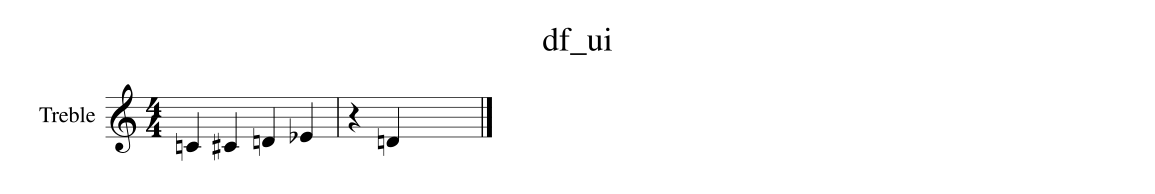

Rendered 1 page(s). Variables available: MEI_LAST, MUSICXML_LAST.


In [8]:
from py_scripts.music21_render import (
    df_to_music21,
    music21_to_musicxml_string,
    render_with_verovio_from_musicxml,
)

# Example: render df_ui (created above). If not present, fall back to a tiny demo
target_df = df_ui
target_df_name = 'df_ui'

for name, value in globals().items():
    if value is target_df and name not in {'target_df', 'target_df_name'}:
        target_df_name = name
        break

score = df_to_music21(
    target_df,
    time_signature='4/4',
    unit_quarter_length=1.0,
    piece_title=target_df_name,
    clef_config='AUTO', # 'G', 'F', 'GF', or 'AUTO'
    split_midi=59,
    voices_per_stave=1,  # 1 or 2
    enforce_accidentals=True,  # force naturals/sharps/flats to be shown
)
musicxml_str = music21_to_musicxml_string(score)
mei_str, svg_pages = render_with_verovio_from_musicxml(musicxml_str, scale=55)

# Expose strings for export if needed
MEI_LAST = mei_str
MUSICXML_LAST = musicxml_str
print(f"Rendered {len(svg_pages)} page(s). Variables available: MEI_LAST, MUSICXML_LAST.")


In [39]:
# Pattern search metrics: convolution and cross-correlation between binary_matrix_df and binary_matrix_ui
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import LinearColorMapper, ColorBar
from bokeh.palettes import Viridis256
from tqdm.auto import tqdm

STRIDE_Y = 1  # step along pitch axis (rows); increase to prefer octave/tonality jumps
STRIDE_X = 1  # step along time axis (columns)
TOP_N_MATCHES = 20  # number of highest-scoring positions to report per metric
PLOT_THRESHOLDS = {
    'normalized_overlap': 0,  # e.g., 0.6 to keep only strong overlaps
    'cross_covariance': None,
    'normalized_cross_correlation': None,
}
MPL_CMAP = 'viridis'

METRICS_TO_RUN = ['normalized_overlap'] # 'normalized_overlap', 'cross_covariance', 'normalized_cross_correlation'
KERNEL_SCALE_FACTORS = [1]  # e.g., [0.5, 0.75, 1.0, 1.5, 2.0]
KERNEL_SCALE_AXES = ['x']  # options: 'x', 'y', 'both'
PLOT_SCALED_KERNELS = False
BINARIZE_SCALED_KERNEL = True  # If True, threshold scaled kernels to {0,1}
BINARIZE_THRESHOLD = 0.5        # Threshold used when binarizing scaled kernels
SHARE_Y_SCALING = True  # Share colorbar scaling across plots when multiple scale factors are used\n

backend_to_use = globals().get('PLOTTING_BACKEND', 'plt')
try:
    output_notebook(hide_banner=True)
except TypeError:
    output_notebook()

AVAILABLE_METRICS = {
    'normalized_overlap': {'label': 'Normalised overlap'},
    'cross_covariance': {'label': 'Cross-covariance'},
    'normalized_cross_correlation': {'label': 'Normalised cross-correlation'},
}

if 'binary_matrix_df' not in globals() or 'binary_matrix_ui' not in globals():
    raise NameError('Run the previous cells to define binary_matrix_df and binary_matrix_ui.')

matrix_source = binary_matrix_df
if isinstance(matrix_source, pd.DataFrame):
    matrix = matrix_source.to_numpy(dtype=float)
    row_labels_full = list(matrix_source.index)
    col_labels_full = list(matrix_source.columns)
else:
    matrix = np.asarray(matrix_source, dtype=float)
    if matrix.ndim != 2:
        raise ValueError('binary_matrix_df must be a 2D table or array.')
    row_labels_full = list(range(matrix.shape[0]))
    col_labels_full = list(range(matrix.shape[1]))

kernel_candidate = binary_matrix_ui
if isinstance(kernel_candidate, pd.DataFrame):
    kernel_array = kernel_candidate.to_numpy(dtype=float)
else:
    kernel_array = np.asarray(kernel_candidate, dtype=float)

if kernel_array.ndim != 2:
    raise ValueError('binary_matrix_ui must be a 2D structure to act as a kernel.')

if kernel_array.size == 0:
    raise ValueError('binary_matrix_ui is empty; draw a pattern before running the analysis cell.')

selected_metrics = [m for m in METRICS_TO_RUN if m in AVAILABLE_METRICS]
if not selected_metrics:
    raise ValueError('METRICS_TO_RUN does not include any supported metrics.')

print(f'Source binary_matrix_df shape: {matrix.shape}')
print(f'Base kernel shape: {kernel_array.shape}')
print(f'Stride (Y, X): ({STRIDE_Y}, {STRIDE_X})')
print('Metrics to run:', ', '.join(AVAILABLE_METRICS[m]['label'] for m in selected_metrics))

def resize_kernel(arr, scale_y, scale_x):
    arr = np.asarray(arr, dtype=float)
    src_rows, src_cols = arr.shape
    tgt_rows = max(1, int(round(src_rows * scale_y)))
    tgt_cols = max(1, int(round(src_cols * scale_x)))
    if tgt_rows == src_rows and tgt_cols == src_cols:
        return arr.copy()
    y_grid = np.linspace(0, src_rows - 1, tgt_rows)
    x_grid = np.linspace(0, src_cols - 1, tgt_cols)
    y0 = np.floor(y_grid).astype(int)
    y1 = np.clip(y0 + 1, 0, src_rows - 1)
    wy = y_grid - y0
    x0 = np.floor(x_grid).astype(int)
    x1 = np.clip(x0 + 1, 0, src_cols - 1)
    wx = x_grid - x0
    top = (1 - wx) * arr[y0[:, None], x0] + wx * arr[y0[:, None], x1]
    bottom = (1 - wx) * arr[y1[:, None], x0] + wx * arr[y1[:, None], x1]
    return (1 - wy)[:, None] * top + wy[:, None] * bottom

def summarize_best(name, data, labels_y, labels_x):
    finite_mask = np.isfinite(data)
    if not finite_mask.any():
        print(f'{name}: no finite values to summarise.')
        return
    flat_index = np.nanargmax(data)
    r, c = divmod(flat_index, data.shape[1])
    print(f'{name} best: {data[r, c]:.3f} at top-left (row={labels_y[r]}, col={labels_x[c]})')

def top_matches(name, data, labels_y, labels_x, top_n, threshold=None):
    if top_n is None or top_n <= 0:
        return
    flat = data.reshape(-1)
    mask = np.isfinite(flat)
    if threshold is not None:
        mask &= flat >= threshold
    indices = np.nonzero(mask)[0]
    if indices.size == 0:
        print(f'{name}: no entries meet the threshold.')
        return
    ranked = indices[np.argsort(flat[indices])[::-1]]
    limit = min(top_n, ranked.size)
    print(f'{name} top {limit} positions:')
    for idx in ranked[:limit]:
        val = flat[idx]
        r, c = divmod(idx, data.shape[1])
        print(f'  score={val:.3f} at row={labels_y[r]}, col={labels_x[c]}')

def apply_threshold(data, threshold):
    if threshold is None:
        return data
    return np.where(data >= threshold, data, np.nan)

def finite_bounds(data):
    finite = data[np.isfinite(data)]
    if finite.size == 0:
        return 0.0, 1.0
    low = float(finite.min())
    high = float(finite.max())
    if low == high:
        high = low + 1e-9
    return low, high

def plot_matplotlib_single(title, data, threshold=None, color_bounds=None):
    fig, ax = plt.subplots(figsize=(9, 6))
    masked = apply_threshold(data, threshold)
    if color_bounds is None:
        vmin, vmax = None, None
    else:
        vmin, vmax = color_bounds
    im = ax.imshow(masked, cmap=MPL_CMAP, origin='upper', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('time offset (columns)')
    ax.set_ylabel('pitch offset (rows)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

def plot_bokeh_single(title, data, threshold=None, color_bounds=None):
    masked = apply_threshold(data, threshold)
    if color_bounds is None:
        low, high = finite_bounds(masked)
    else:
        low, high = color_bounds
    fig = figure(
        title=title,
        x_range=(0, masked.shape[1]),
        y_range=(0, masked.shape[0]),
        width=900,
        height=600,
        tools='pan,wheel_zoom,reset,save',
    )
    mapper = LinearColorMapper(palette=Viridis256, low=low, high=high)
    fig.image(image=[np.flipud(masked)], x=0, y=0, dw=masked.shape[1], dh=masked.shape[0], color_mapper=mapper)
    fig.add_layout(ColorBar(color_mapper=mapper), 'right')
    fig.xaxis.axis_label = 'time offset (columns)'
    fig.yaxis.axis_label = 'pitch offset (rows, top=high)'
    show(fig)

def plot_kernel(title, kernel):
    if backend_to_use in ('plt', 'both'):
        fig, ax = plt.subplots(figsize=(9, 6))
        im = ax.imshow(kernel, cmap=MPL_CMAP, origin='upper', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel('kernel columns')
        ax.set_ylabel('kernel rows')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.show()
    if backend_to_use in ('bokeh', 'both'):
        low, high = finite_bounds(kernel)
        fig = figure(
            title=title,
            x_range=(0, kernel.shape[1]),
            y_range=(0, kernel.shape[0]),
            width=900,
            height=600,
            tools='pan,wheel_zoom,reset,save',
        )
        mapper = LinearColorMapper(palette=Viridis256, low=low, high=high)
        fig.image(image=[np.flipud(kernel)], x=0, y=0, dw=kernel.shape[1], dh=kernel.shape[0], color_mapper=mapper)
        fig.add_layout(ColorBar(color_mapper=mapper), 'right')
        fig.xaxis.axis_label = 'kernel columns'
        fig.yaxis.axis_label = 'kernel rows (top=high)'
        show(fig)

scale_variants = []
seen_scales = set()
for axis in KERNEL_SCALE_AXES:
    axis_norm = axis.lower()
    if axis_norm not in {'x', 'y', 'both'}:
        raise ValueError(f'Unsupported axis {axis!r} in KERNEL_SCALE_AXES; use "x", "y", or "both".')
    for factor in KERNEL_SCALE_FACTORS:
        factor = float(factor)
        if factor <= 0:
            raise ValueError(f'Scale factor must be positive; received {factor}.')
        scale_y = factor if axis_norm in {'y', 'both'} else 1.0
        scale_x = factor if axis_norm in {'x', 'both'} else 1.0
        key = (round(scale_y, 6), round(scale_x, 6))
        if key in seen_scales:
            continue
        seen_scales.add(key)
        label = f'axis={axis_norm}, factor={factor:g}, scale_y={scale_y:.3f}, scale_x={scale_x:.3f}'
        scale_variants.append({'axis': axis_norm, 'factor': factor, 'scale_y': scale_y, 'scale_x': scale_x, 'label': label})

if (1.0, 1.0) not in seen_scales:
    scale_variants.insert(0, {
        'axis': 'both',
        'factor': 1.0,
        'scale_y': 1.0,
        'scale_x': 1.0,
        'label': 'axis=both, factor=1, scale_y=1.000, scale_x=1.000',
    })

print(f'Kernel scale variants to evaluate: {len(scale_variants)}')

all_results = {}
scaled_kernels = {}
last_variant_key = None
last_conv_raw_df = None

# Storage for global color bounds when sharing is enabled
_shared_bounds = {m: [np.inf, -np.inf] for m in AVAILABLE_METRICS.keys()}
# Defer plots per variant if sharing is enabled
_deferred_plots = []

for variant in tqdm(scale_variants, desc='Kernel variants'):
    scale_y = variant['scale_y']
    scale_x = variant['scale_x']
    variant_key = variant['label']
    scaled_kernel = resize_kernel(kernel_array, scale_y, scale_x)
    if bool(globals().get('BINARIZE_SCALED_KERNEL', False)):
        _thr = float(globals().get('BINARIZE_THRESHOLD', 0.5))
        scaled_kernel = (scaled_kernel >= _thr).astype(float)
    tqdm.write(f'Processing {variant_key} -> shape={scaled_kernel.shape}')
    if PLOT_SCALED_KERNELS:
        plot_kernel(f'Scaled kernel ({variant_key})', scaled_kernel)

    if scaled_kernel.shape[0] > matrix.shape[0] or scaled_kernel.shape[1] > matrix.shape[1]:
        tqdm.write('  Skipped: scaled kernel is larger than the source matrix.')
        continue

    window_shape = scaled_kernel.shape
    out_rows = matrix.shape[0] - window_shape[0] + 1
    out_cols = matrix.shape[1] - window_shape[1] + 1
    if out_rows <= 0 or out_cols <= 0:
        tqdm.write('  Skipped: kernel cannot slide within the source matrix.')
        continue

    windows = np.lib.stride_tricks.sliding_window_view(matrix, window_shape)
    conv_scores_full = (windows * scaled_kernel).sum(axis=(-2, -1))

    metric_arrays = {}
    metric_dfs = {}

    row_positions = list(range(0, out_rows, max(1, int(STRIDE_Y))))
    col_positions = list(range(0, out_cols, max(1, int(STRIDE_X))))
    row_labels = [row_labels_full[pos] for pos in row_positions]
    col_labels = [col_labels_full[pos] for pos in col_positions]

    if 'normalized_overlap' in selected_metrics:
        kernel_weight = scaled_kernel.sum()
        if kernel_weight != 0:
            conv_norm_full = conv_scores_full / kernel_weight
        else:
            conv_norm_full = conv_scores_full.astype(float)
        conv_norm = conv_norm_full[np.ix_(row_positions, col_positions)]
        metric_arrays['normalized_overlap'] = conv_norm
        metric_dfs['normalized_overlap'] = pd.DataFrame(conv_norm, index=row_labels, columns=col_labels)
        conv_raw = conv_scores_full[np.ix_(row_positions, col_positions)]
        last_conv_raw_df = pd.DataFrame(conv_raw, index=row_labels, columns=col_labels)

    needs_cross = any(m in selected_metrics for m in ('cross_covariance', 'normalized_cross_correlation'))
    if needs_cross:
        windows_flat = windows.reshape(out_rows, out_cols, -1)
        kernel_flat = scaled_kernel.reshape(-1)
        kernel_mean = kernel_flat.mean()
        kernel_zero_mean = kernel_flat - kernel_mean
        kernel_norm_val = np.linalg.norm(kernel_zero_mean)
        window_means = windows_flat.mean(axis=2, keepdims=True)
        windows_zero_mean = windows_flat - window_means
        window_norms = np.linalg.norm(windows_zero_mean, axis=2)
        cross_cov_full = np.tensordot(windows_zero_mean, kernel_zero_mean, axes=([2], [0]))
        if 'cross_covariance' in selected_metrics:
            cross_cov = cross_cov_full[np.ix_(row_positions, col_positions)]
            metric_arrays['cross_covariance'] = cross_cov
            metric_dfs['cross_covariance'] = pd.DataFrame(cross_cov, index=row_labels, columns=col_labels)
        if 'normalized_cross_correlation' in selected_metrics:
            denominator = window_norms * kernel_norm_val
            norm_cross_full = np.divide(
                cross_cov_full,
                denominator,
                out=np.zeros_like(cross_cov_full),
                where=denominator > 0,
            )
            norm_cross = norm_cross_full[np.ix_(row_positions, col_positions)]
            metric_arrays['normalized_cross_correlation'] = norm_cross
            metric_dfs['normalized_cross_correlation'] = pd.DataFrame(norm_cross, index=row_labels, columns=col_labels)

    for metric_key in selected_metrics:
        metric_label = AVAILABLE_METRICS[metric_key]['label']
        data = metric_arrays.get(metric_key)
        if data is None:
            continue
        summarize_best(metric_label, data, row_labels, col_labels)
        threshold = PLOT_THRESHOLDS.get(metric_key)
        top_matches(metric_label, data, row_labels, col_labels, TOP_N_MATCHES, threshold)

        share_scale = bool(SHARE_Y_SCALING) and len(scale_variants) > 1
        if share_scale:
            masked = apply_threshold(data, threshold)
            if np.isfinite(masked).any():
                low, high = finite_bounds(masked)
                bounds = _shared_bounds.get(metric_key)
                if bounds is not None:
                    bounds[0] = min(bounds[0], low)
                    bounds[1] = max(bounds[1], high)
            _deferred_plots.append({
                'metric_key': metric_key,
                'metric_label': metric_label,
                'data': data,
                'threshold': threshold,
            })
        else:
            if backend_to_use == 'plt':
                plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=None)
            elif backend_to_use == 'bokeh':
                plot_bokeh_single(metric_label, data, threshold=threshold, color_bounds=None)
            elif backend_to_use == 'both':
                plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=None)
                plot_bokeh_single(metric_label, data, threshold=threshold, color_bounds=None)
            elif backend_to_use == 'none':
                pass
            else:
                msg = "Unknown backend {backend!r}. Available options: 'plt', 'bokeh', 'both', 'none'. Defaulting to Matplotlib."
                print(msg.format(backend=backend_to_use))
                plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=None)

    all_results[variant_key] = metric_dfs
    scaled_kernels[variant_key] = scaled_kernel
    last_variant_key = variant_key

# After processing all variants, render deferred plots with shared color scale if requested
if bool(SHARE_Y_SCALING) and len(scale_variants) > 1 and _deferred_plots:
    # Compute final bounds per metric from accumulated mins/maxes
    final_bounds = {}
    for m, (lo, hi) in _shared_bounds.items():
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            final_bounds[m] = (lo, hi)
    # Render all deferred plots using these bounds
    for item in _deferred_plots:
        metric_key = item['metric_key']
        metric_label = item['metric_label']
        data = item['data']
        threshold = item['threshold']
        bounds = final_bounds.get(metric_key)
        if backend_to_use == 'plt':
            plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=bounds)
        elif backend_to_use == 'bokeh':
            plot_bokeh_single(metric_label, data, threshold=threshold, color_bounds=bounds)
        elif backend_to_use == 'both':
            plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=bounds)
            plot_bokeh_single(metric_label, data, threshold=threshold, color_bounds=bounds)
        elif backend_to_use == 'none':
            pass
        else:
            msg = "Unknown backend {backend!r}. Available options: 'plt', 'bokeh', 'both', 'none'. Defaulting to Matplotlib."
            print(msg.format(backend=backend_to_use))
            plot_matplotlib_single(metric_label, data, threshold=threshold, color_bounds=bounds)

pattern_search_results = all_results
pattern_search_kernels = scaled_kernels
last_pattern_search_variant = last_variant_key

if last_variant_key is not None:
    last_metrics = all_results[last_variant_key]
    conv_norm_df = last_metrics.get('normalized_overlap')
    cross_cov_df = last_metrics.get('cross_covariance')
    norm_cross_df = last_metrics.get('normalized_cross_correlation')
else:
    conv_norm_df = None
    cross_cov_df = None
    norm_cross_df = None

conv_raw_df = last_conv_raw_df
print('Stored results in pattern_search_results; last variant key:', last_variant_key)


Source binary_matrix_df shape: (128, 98)
Base kernel shape: (12, 12)
Stride (Y, X): (1, 1)
Metrics to run: Normalised overlap
Kernel scale variants to evaluate: 1


Kernel variants:   0%|          | 0/1 [00:00<?, ?it/s]

Processing axis=x, factor=1, scale_y=1.000, scale_x=1.000 -> shape=(12, 12)
Normalised overlap best: 0.700 at top-left (row=54, col=4)
Normalised overlap top 20 positions:
  score=0.700 at row=54, col=48
  score=0.700 at row=54, col=82
  score=0.700 at row=58, col=18
  score=0.700 at row=54, col=4
  score=0.600 at row=57, col=40
  score=0.600 at row=49, col=38
  score=0.600 at row=54, col=3
  score=0.600 at row=59, col=16
  score=0.600 at row=64, col=44
  score=0.600 at row=54, col=49
  score=0.600 at row=66, col=31
  score=0.500 at row=53, col=66
  score=0.500 at row=53, col=65
  score=0.500 at row=66, col=30
  score=0.500 at row=53, col=67
  score=0.500 at row=53, col=64
  score=0.500 at row=59, col=86
  score=0.500 at row=54, col=51
  score=0.500 at row=51, col=56
  score=0.500 at row=54, col=50


Stored results in pattern_search_results; last variant key: axis=x, factor=1, scale_y=1.000, scale_x=1.000


### Annotated single-position convolution demo

This demo shows exactly how the convolution score is computed for one placement of the UI kernel on the binary matrix.

- **Source matrix**: $M \in \mathbb{R}^{R \times C}$ (your `binary_matrix_df`)
- **Kernel**: $K \in \mathbb{R}^{r \times c}$ (your `binary_matrix_ui`)
- **Placement**: top-left at $(i, j)$ in $M$ so the kernel fully fits inside $M$

For that placement, the raw score is the element-wise product summed over the kernel window:

$$
S(i, j) = \sum_{u=0}^{r-1} \sum_{v=0}^{c-1}
M[i+u, j+v]\cdot K[u, v]
$$

With binary $K$, this counts the number of overlapping 1s. The normalised-overlap score is:

$$
\hat{S}(i, j) =
\begin{cases}
\dfrac{S(i, j)}{\sum_{u,v} K[u,v]} & \text{if } \sum_{u,v} K[u,v] > 0 \\
S(i, j) & \text{otherwise}
\end{cases}
$$

The code below:
- draws a rectangle on the full matrix at the chosen $(i, j)$;
- shows the matrix window $M[i:i+r, j:j+c]$, the kernel $K$, and their element-wise product;
- prints both $S(i, j)$ and the normalised score $\hat{S}(i, j)$. 

Demo placement top-left (row=54, col=20) with window shape (12, 12)
Raw overlap S(i,j) = sum(W*K) = 3.000000
Kernel sum = 10.000000; Normalised overlap = 0.300000

=== Kernel Sum Breakdown ===
  K[0,0]=0 | K[0,1]=0 | K[0,2]=0 | K[0,3]=0 | K[0,4]=0 | K[0,5]=0 | K[0,6]=0 | K[0,7]=0 | K[0,8]=0 | K[0,9]=0 | K[0,10]=0 | K[0,11]=0
  K[1,0]=0 | K[1,1]=0 | K[1,2]=0 | K[1,3]=0 | K[1,4]=0 | K[1,5]=0 | K[1,6]=0 | K[1,7]=0 | K[1,8]=0 | K[1,9]=0 | K[1,10]=0 | K[1,11]=0
  K[2,0]=0 | K[2,1]=0 | K[2,2]=0 | K[2,3]=0 | K[2,4]=0 | K[2,5]=0 | K[2,6]=0 | K[2,7]=0 | K[2,8]=0 | K[2,9]=0 | K[2,10]=0 | K[2,11]=0
  K[3,0]=0 | K[3,1]=0 | K[3,2]=0 | K[3,3]=0 | K[3,4]=0 | K[3,5]=0 | K[3,6]=0 | K[3,7]=0 | K[3,8]=0 | K[3,9]=0 | K[3,10]=0 | K[3,11]=0
  K[4,0]=0 | K[4,1]=0 | K[4,2]=0 | K[4,3]=0 | K[4,4]=0 | K[4,5]=0 | K[4,6]=0 | K[4,7]=0 | K[4,8]=0 | K[4,9]=0 | K[4,10]=0 | K[4,11]=0
  K[5,0]=0 | K[5,1]=0 | K[5,2]=0 | K[5,3]=0 | K[5,4]=0 | K[5,5]=0 | K[5,6]=0 | K[5,7]=0 | K[5,8]=0 | K[5,9]=0 | K[5,10]=0 | K[5,11]=0
  K

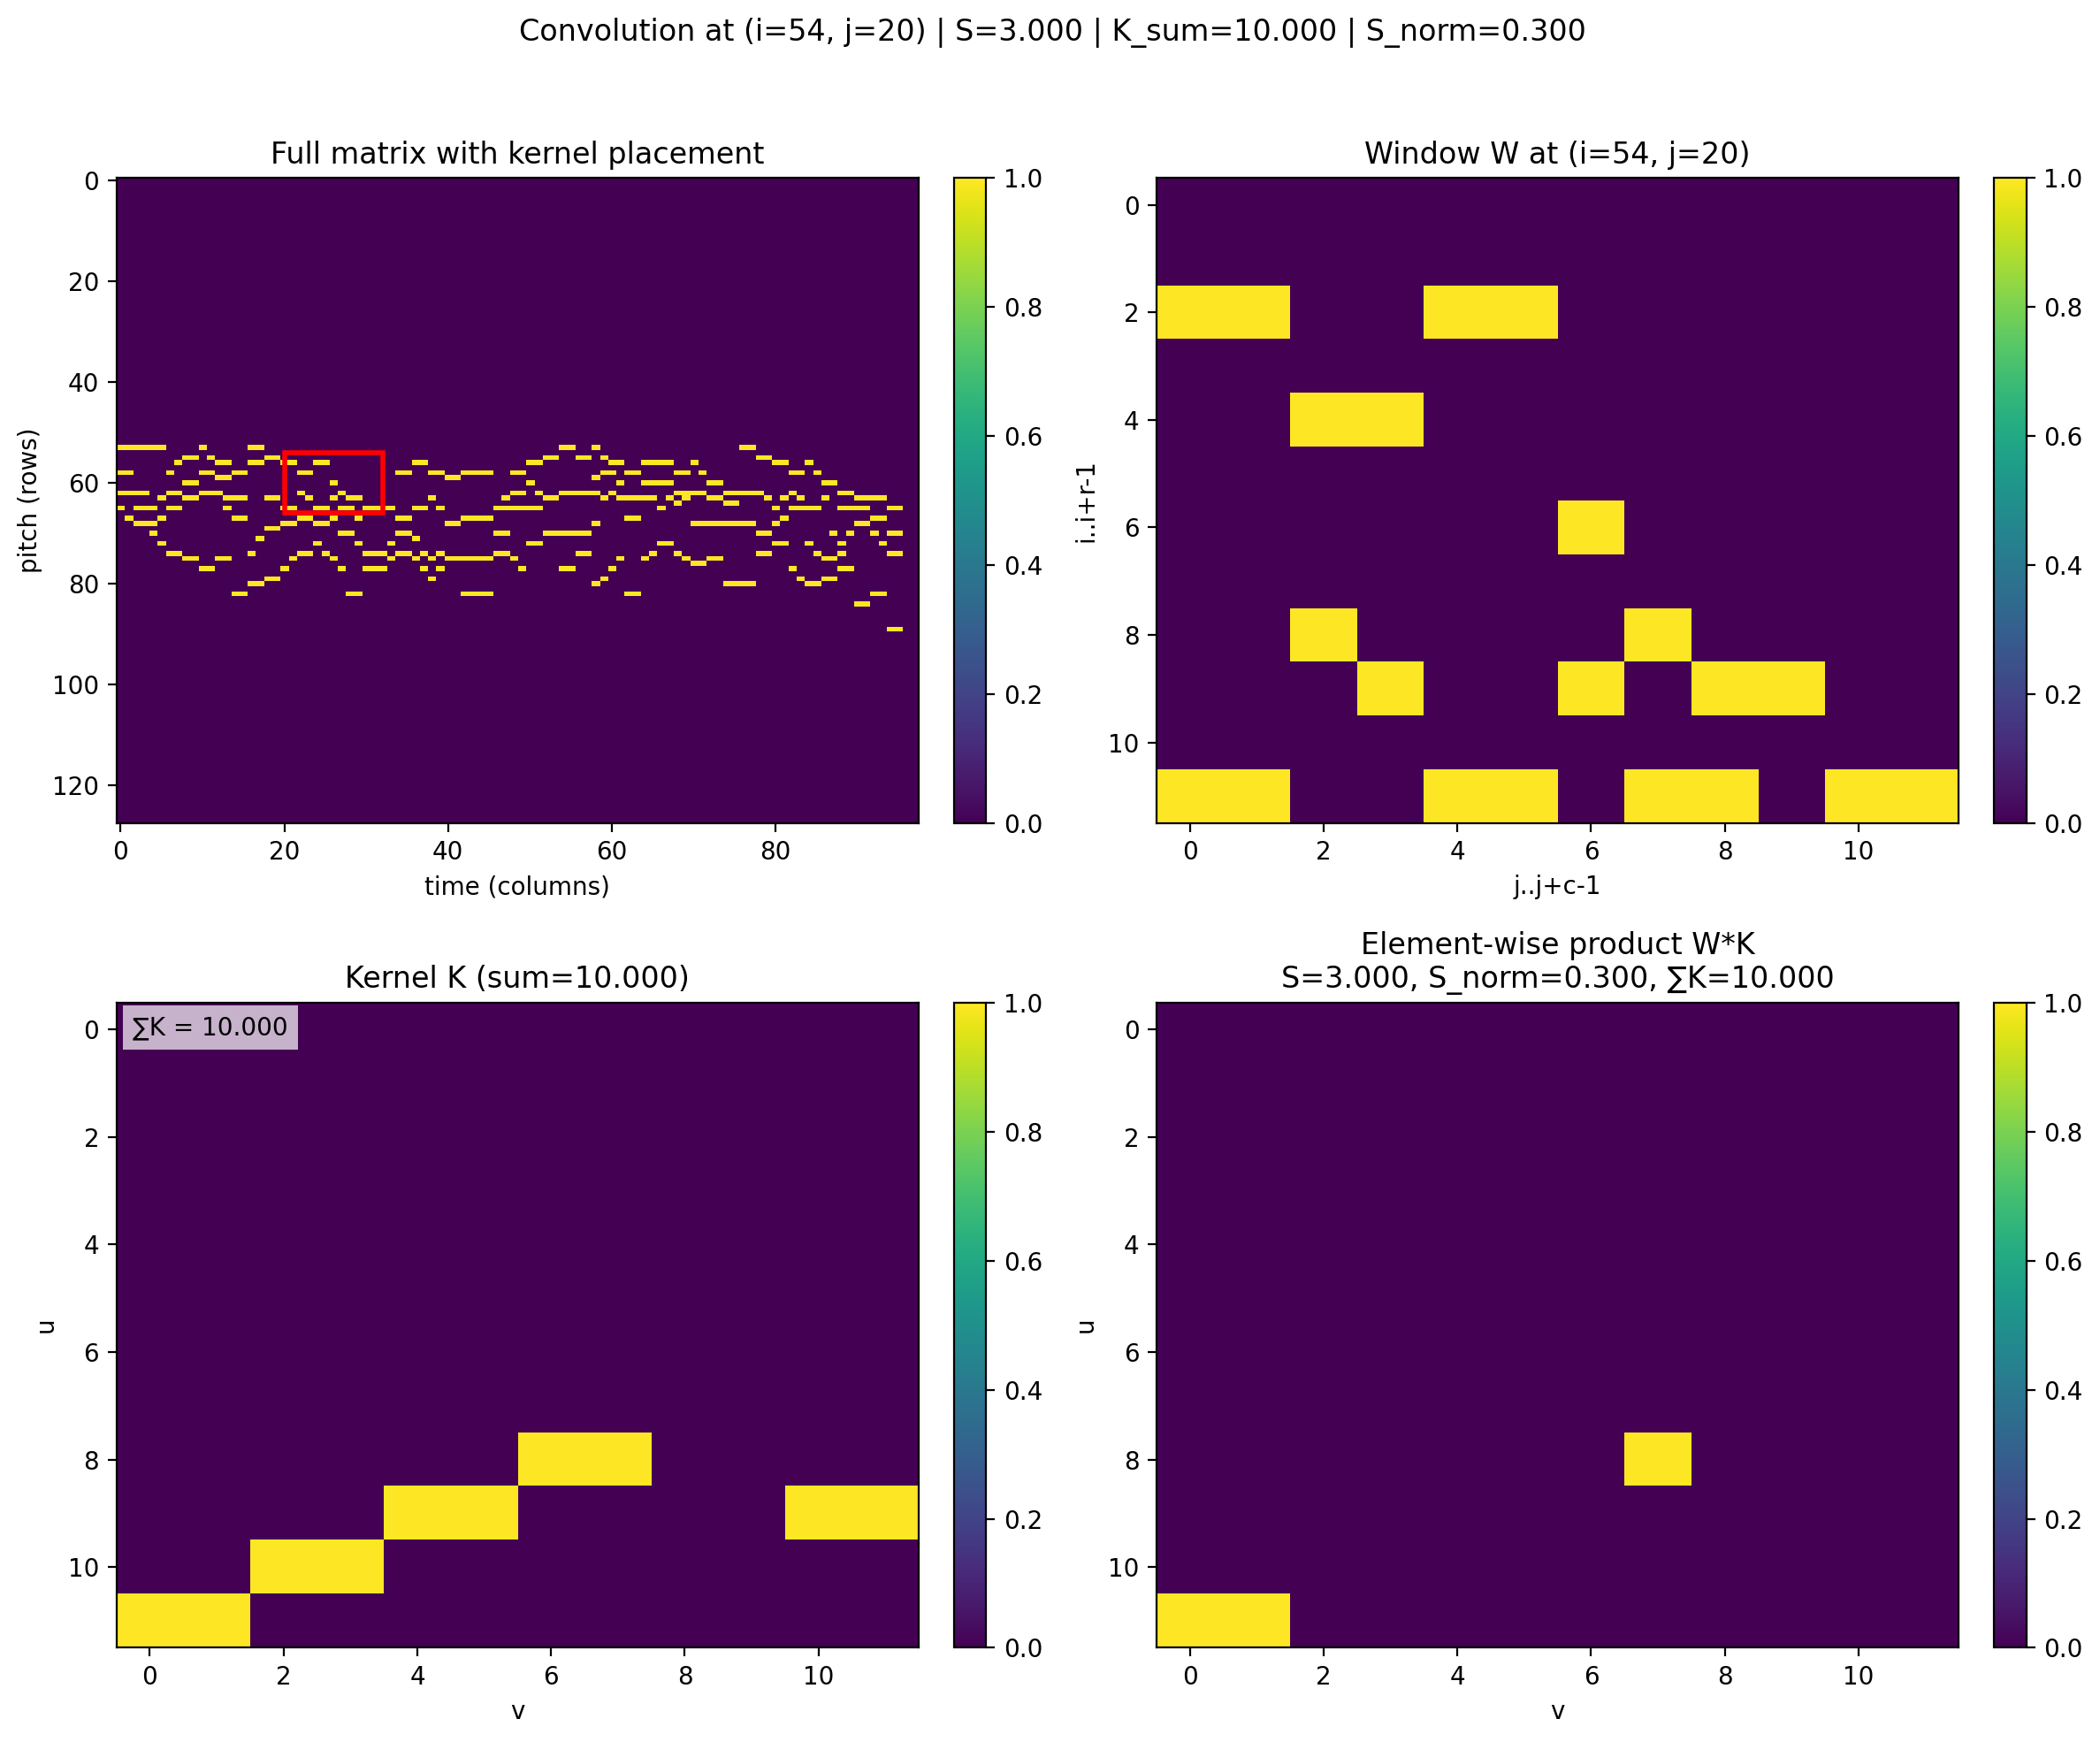

In [20]:
# Single-position convolution illustration with annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- helpers ----------
def print_kernel_sum_breakdown(K, row_labels=None, col_labels=None, max_verbose_size=144):
    r, c = K.shape
    print("\n=== Kernel Sum Breakdown ===")
    if r*c <= max_verbose_size:
        total = 0.0
        for u in range(r):
            row_terms = []
            for v in range(c):
                lab_r = row_labels[u] if row_labels is not None else u
                lab_c = col_labels[v] if col_labels is not None else v
                val = float(K[u, v])
                total += val
                row_terms.append(f"K[{lab_r},{lab_c}]={val:.6g}")
            print("  " + " | ".join(row_terms))
        row_sums = K.sum(axis=1)
        print("  Row sums: " + " | ".join(f"{float(x):.6g}" for x in row_sums))
        col_sums = K.sum(axis=0)
        print("  Col sums: " + " | ".join(f"{float(x):.6g}" for x in col_sums))
        print(f"  Total kernel sum = {total:.6g}")
    else:
        row_sums = K.sum(axis=1)
        col_sums = K.sum(axis=0)
        total = float(K.sum())
        print(f"  (Window too large for elementwise listing; showing row/col sums)")
        print("  Row sums: " + " | ".join(f"{float(x):.6g}" for x in row_sums))
        print("  Col sums: " + " | ".join(f"{float(x):.6g}" for x in col_sums))
        print(f"  Total kernel sum = {total:.6g}")
    return float(K.sum())

def print_convolution_breakdown(W, K, i0, j0, row_labels_full, col_labels_full, max_verbose_size=144):
    r, c = K.shape
    print("\n=== Convolution Breakdown at placement (i,j)=({}, {}) ===".format(i0, j0))
    print("  Using absolute matrix indices and labels (pitch=row, time=col).")
    Prod = W * K
    if r*c <= max_verbose_size:
        # Element-wise terms
        total = 0.0
        for u in range(r):
            row_terms = []
            for v in range(c):
                ii = i0 + u
                jj = j0 + v
                lab_r = row_labels_full[ii]
                lab_c = col_labels_full[jj]
                w = float(W[u, v])
                k = float(K[u, v])
                p = w * k
                total += p
                row_terms.append(f"W[{lab_r},{lab_c}]={w:.6g} * K[u={u},v={v}]={k:.6g} -> {p:.6g}")
            print("  " + " | ".join(row_terms))
        # Row/col partials of product
        row_sums = Prod.sum(axis=1)
        col_sums = Prod.sum(axis=0)
        print("  Row partial sums (∑ over v of W*K): " + " | ".join(f"{float(x):.6g}" for x in row_sums))
        print("  Col partial sums (∑ over u of W*K): " + " | ".join(f"{float(x):.6g}" for x in col_sums))
        print(f"  Total raw overlap S = {total:.6g}")
    else:
        print("  (Window too large for elementwise listing; showing row/col sums)")
        row_sums = Prod.sum(axis=1)
        col_sums = Prod.sum(axis=0)
        total = float(Prod.sum())
        print("  Row partial sums (∑ over v of W*K): " + " | ".join(f"{float(x):.6g}" for x in row_sums))
        print("  Col partial sums (∑ over u of W*K): " + " | ".join(f"{float(x):.6g}" for x in col_sums))
        print(f"  Total raw overlap S = {total:.6g}")
    return Prod

# ---------- resolve matrices ----------
if isinstance(binary_matrix_df, pd.DataFrame):
    M = binary_matrix_df.to_numpy(dtype=float)
    row_labels_full = list(binary_matrix_df.index)
    col_labels_full = list(binary_matrix_df.columns)
else:
    M = np.asarray(binary_matrix_df, dtype=float)
    row_labels_full = list(range(M.shape[0]))
    col_labels_full = list(range(M.shape[1]))

K_input = binary_matrix_ui
K = K_input.to_numpy(dtype=float) if isinstance(K_input, pd.DataFrame) else np.asarray(K_input, dtype=float)

# # Optionally reuse a scaled kernel used above (e.g., best variant)
# desired_variant_key = globals().get('last_pattern_search_variant', None)
# if desired_variant_key and 'pattern_search_kernels' in globals() and desired_variant_key in pattern_search_kernels:
#     K = np.asarray(pattern_search_kernels[desired_variant_key], dtype=float)

r, c = K.shape
R, C = M.shape

# Set the demo position manually (row, column indices)
DEMO_CONV_POS = (54, 20)  # This will place the kernel at row 25, column 40


# # ---------- choose demo position ----------
demo_pos = globals().get('DEMO_CONV_POS', None)
# if demo_pos is None:
#     i = j = None
#     try:
#         last_key = globals().get('last_pattern_search_variant', None)
#         if last_key is not None and 'pattern_search_results' in globals():
#             last_metrics = pattern_search_results.get(last_key, {})
#             conv_norm_df = last_metrics.get('normalized_overlap')
#             if conv_norm_df is not None and hasattr(conv_norm_df, 'to_numpy'):
#                 arr = conv_norm_df.to_numpy(dtype=float)
#                 idx = np.nanargmax(arr)
#                 i_rel, j_rel = divmod(idx, arr.shape[1])
#                 i = i_rel * max(1, int(STRIDE_Y))
#                 j = j_rel * max(1, int(STRIDE_X))
#     except Exception:
#         i = j = None
#     if i is None or j is None:
#         i = 0
#         j = 0
#     demo_pos = (int(i), int(j))

# Clamp to fit
i, j = demo_pos
i = max(0, min(i, R - r))
j = max(0, min(j, C - c))
demo_pos = (i, j)

# ---------- compute window, products, sums ----------
W = M[i:i+r, j:j+c]
Prod = W * K
S_raw = float(Prod.sum())
K_sum = float(K.sum())
S_norm = (S_raw / K_sum) if K_sum > 0 else S_raw

print(f"Demo placement top-left (row={row_labels_full[i]}, col={col_labels_full[j]}) with window shape {W.shape}")
print(f"Raw overlap S(i,j) = sum(W*K) = {S_raw:.6f}")
print(f"Kernel sum = {K_sum:.6f}; Normalised overlap = {S_norm:.6f}")

# ---------- detailed printouts ----------
MAX_VERBOSE_SIZE = 12 * 12  # tweak as you like
# Full breakdown of kernel sum
_ = print_kernel_sum_breakdown(
    K,
    row_labels=list(range(r)),  # kernel rows/cols are relative; keep indices here
    col_labels=list(range(c)),
    max_verbose_size=MAX_VERBOSE_SIZE,
)
# Detailed breakdown of the convolution at (i,j)
_ = print_convolution_breakdown(
    W, K, i, j,
    row_labels_full=row_labels_full,
    col_labels_full=col_labels_full,
    max_verbose_size=MAX_VERBOSE_SIZE,
)

# ---------- visuals ----------
# default cmap fallback if not defined
try:
    MPL_CMAP
except NameError:
    MPL_CMAP = 'viridis'

fig = plt.figure(figsize=(12, 10))
fig.suptitle(f'Convolution at (i={i}, j={j}) | S={S_raw:.3f} | K_sum={K_sum:.3f} | S_norm={S_norm:.3f}', y=0.98)

# 1) Full matrix view with rectangle
ax0 = fig.add_subplot(2, 2, 1)
im0 = ax0.imshow(M, cmap=MPL_CMAP, origin='upper', aspect='auto')
ax0.add_patch(Rectangle((j, i), c, r, fill=False, edgecolor='red', linewidth=2))
ax0.set_title('Full matrix with kernel placement')
ax0.set_xlabel('time (columns)')
ax0.set_ylabel('pitch (rows)')
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

# 2) Window W
ax1 = fig.add_subplot(2, 2, 2)
im1 = ax1.imshow(W, cmap=MPL_CMAP, origin='upper', aspect='auto', vmin=M.min(), vmax=M.max())
ax1.set_title(f'Window W at (i={i}, j={j})')
ax1.set_xlabel('j..j+c-1')
ax1.set_ylabel('i..i+r-1')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 3) Kernel K (title shows kernel sum)
ax2 = fig.add_subplot(2, 2, 3)
im2 = ax2.imshow(K, cmap=MPL_CMAP, origin='upper', aspect='auto')
ax2.set_title(f'Kernel K (sum={K_sum:.3f})')
ax2.set_xlabel('v')
ax2.set_ylabel('u')
# Optional on-plot text box with the sum (redundant but handy):
ax2.text(0.02, 0.98, f'∑K = {K_sum:.3f}', transform=ax2.transAxes,
         va='top', ha='left', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 4) Element-wise product W*K
ax3 = fig.add_subplot(2, 2, 4)
im3 = ax3.imshow(Prod, cmap=MPL_CMAP, origin='upper', aspect='auto')
ax3.set_title(f'Element-wise product W*K\nS={S_raw:.3f}, S_norm={S_norm:.3f}, ∑K={K_sum:.3f}')
ax3.set_xlabel('v')
ax3.set_ylabel('u')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Pattern Search Metrics Overview

- **Normalised overlap** divides the raw overlap count by the sum of kernel values. With binary kernels this ranges from 0 (no overlap) to 1 (perfect alignment). Values above 1 only appear if the kernel contains weights greater than 1.
- **Cross-covariance** subtracts the local mean before scoring. The scale depends on the data magnitude; higher positive numbers indicate stronger alignment with the kernel's on/off pattern, while negative values suggest an inverted match.
- **Normalised cross-correlation** rescales cross-covariance by both vector norms, yielding scores in [-1, 1]. A value of 1 is a perfect positive match, 0 indicates no linear relationship, and -1 is a perfect inversion.
- <code>METRICS_TO_RUN</code> lets you choose which metrics to evaluate and plot. Remove entries to skip heavy calculations.
- <code>PLOT_THRESHOLDS</code> supplies a per-metric cutoff used for both the heatmaps and the top-N match listings.
- <code>KERNEL_SCALE_FACTORS</code> and <code>KERNEL_SCALE_AXES</code> generate scaled versions of the UI kernel so you can test augmentations/diminutions. Enable <code>PLOT_SCALED_KERNELS</code> to visualise each variant with the same backend setting.
- <code>BINARIZE_SCALED_KERNEL</code> and <code>BINARIZE_THRESHOLD</code> optionally force scaled kernels to be strictly binary after resizing (default off). This affects analysis and the scaled-kernel visualisation.
- The <code>tqdm</code> progress bar tracks kernel variants; detailed results live in <code>pattern_search_results[variant_key][metric_key]</code>, and the last run variant remains accessible through <code>conv_norm_df</code>, <code>cross_cov_df</code>, <code>norm_cross_df</code>, and <code>conv_raw_df</code>.



to do:

Sliding-window Hamming distance or Sum of Absolute/ squared Differences computed on the binary matrices (optionally vectorized with sliding_window_view).

Self-similarity matrices or recurrence plots to locate repeated motifs independent of a fixed kernel size.

Dynamic Time Warping or sequence alignment on extracted pitch/time contours to tolerate stretching or small rhythmic deviations.

Hashing / locality-sensitive hashing on flattened windows for faster approximate lookups when scanning large corpora.

In [33]:
# Scaled kernel visualization based on `resize_kernel`
# - Overrides: set TEST_SCALE_FACTORS / TEST_SCALE_AXES to custom lists or leave as None to use globals
# - Backend behavior: if using 'plt' or 'both' -> grid of subplots with shared color scale;
#                     if using 'bokeh' or 'both' -> also display per-variant figures via `plot_kernel`

import numpy as np
import matplotlib.pyplot as plt

if 'binary_matrix_ui' not in globals():
    raise NameError('binary_matrix_ui is not defined. Run the UI/designer cell first.')
if 'resize_kernel' not in globals():
    raise NameError('resize_kernel is not defined. Run the metrics cell that defines it first.')

# Optional overrides for quick experimentation
TEST_SCALE_FACTORS = None  # e.g., [0.5, 1.0, 2.0]
TEST_SCALE_AXES = None     # e.g., ['x', 'y', 'both']
TEST_MAX_COLS = 3          # max columns in the Matplotlib grid
TEST_SHARE_COLORS = True   # share color scale (vmin/vmax) across all subplots
TEST_BINARIZE_SCALED_KERNEL = False  # None -> use global; True/False to override
TEST_BINARIZE_THRESHOLD = None      # None -> use global; else float

# Resolve base kernel
kernel_candidate = binary_matrix_ui
base_kernel = kernel_candidate.to_numpy(dtype=float) if hasattr(kernel_candidate, 'to_numpy') else np.asarray(kernel_candidate, dtype=float)

# Resolve factors/axes and binarization settings
factors = TEST_SCALE_FACTORS if TEST_SCALE_FACTORS is not None else globals().get('KERNEL_SCALE_FACTORS', [1.0])
axes_list = TEST_SCALE_AXES if TEST_SCALE_AXES is not None else globals().get('KERNEL_SCALE_AXES', ['both'])
binarize = TEST_BINARIZE_SCALED_KERNEL if TEST_BINARIZE_SCALED_KERNEL is not None else globals().get('BINARIZE_SCALED_KERNEL', False)
binarize_threshold = float(TEST_BINARIZE_THRESHOLD if TEST_BINARIZE_THRESHOLD is not None else globals().get('BINARIZE_THRESHOLD', 0.5))

# Build scale variants (deduplicated by (scale_y, scale_x))
scale_variants = []
seen_scales = set()
for axis in axes_list:
    axis_norm = str(axis).lower()
    if axis_norm not in {'x', 'y', 'both'}:
        raise ValueError(f'Unsupported axis {axis!r}; use "x", "y", or "both".')
    for factor in factors:
        f = float(factor)
        if f <= 0:
            raise ValueError(f'Scale factor must be positive; received {f}.')
        scale_y = f if axis_norm in {'y', 'both'} else 1.0
        scale_x = f if axis_norm in {'x', 'both'} else 1.0
        key = (round(scale_y, 6), round(scale_x, 6))
        if key in seen_scales:
            continue
        seen_scales.add(key)
        label = f'axis={axis_norm}, factor={f:g}, sy={scale_y:.3f}, sx={scale_x:.3f}'
        scaled = resize_kernel(base_kernel, scale_y, scale_x)
        if binarize:
            scaled = (scaled >= binarize_threshold).astype(float)
        scale_variants.append({'label': label, 'kernel': scaled})

# Always include the identity (1.0, 1.0) if not present
if (1.0, 1.0) not in seen_scales:
    scale_variants.insert(0, {
        'label': 'axis=both, factor=1, sy=1.000, sx=1.000',
        'kernel': base_kernel.astype(float, copy=True),
    })

print(f'Visualising {len(scale_variants)} scaled kernels')
for v in scale_variants:
    print(f"  {v['label']} -> shape={v['kernel'].shape}")

# Choose backend (prefer an already-resolved choice if present)
backend_choice = globals().get('backend_to_use', globals().get('PLOTTING_BACKEND', 'plt'))

# Matplotlib grid visualization
if backend_choice in ('plt', 'both'):
    n = len(scale_variants)
    if n == 0:
        print('No variants to plot.')
    else:
        # Compute shared vmin/vmax if requested
        if TEST_SHARE_COLORS:
            mins = [np.nanmin(v['kernel']) if np.isfinite(v['kernel']).any() else 0.0 for v in scale_variants]
            maxs = [np.nanmax(v['kernel']) if np.isfinite(v['kernel']).any() else 1.0 for v in scale_variants]
            vmin = float(np.min(mins))
            vmax = float(np.max(maxs))
            if not np.isfinite(vmin):
                vmin = 0.0
            if not np.isfinite(vmax) or vmax == vmin:
                vmax = vmin + 1e-9
        else:
            vmin = vmax = None

        ncols = int(min(TEST_MAX_COLS, n))
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 4.0 * nrows))
        axes_arr = np.atleast_1d(axes).ravel()

        ims = []
        for idx, (ax, variant) in enumerate(zip(axes_arr, scale_variants)):
            K = variant['kernel']
            im = ax.imshow(K, cmap=globals().get('MPL_CMAP', 'viridis'), origin='upper', aspect='auto', vmin=vmin if vmin is not None else None, vmax=vmax if vmin is not None else None)
            ax.set_title(variant['label'])
            ax.set_xlabel('kernel columns')
            ax.set_ylabel('kernel rows')
            ims.append(im)
        # Hide any leftover axes
        for ax in axes_arr[len(scale_variants):]:
            ax.axis('off')
        # Single shared colorbar if we plotted anything
        if ims:
            fig.colorbar(ims[-1], ax=axes_arr.tolist(), fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

# Bokeh visualization (per-variant) via existing helper
if backend_choice in ('bokeh', 'both'):
    if 'plot_kernel' in globals():
        for v in scale_variants:
            plot_kernel(f"Scaled kernel ({v['label']})", v['kernel'])
    else:
        print("plot_kernel is not available; skip bokeh rendering.")



Visualising 5 scaled kernels
  axis=x, factor=0.5, sy=1.000, sx=0.500 -> shape=(12, 6)
  axis=x, factor=0.75, sy=1.000, sx=0.750 -> shape=(12, 9)
  axis=x, factor=1, sy=1.000, sx=1.000 -> shape=(12, 12)
  axis=x, factor=1.5, sy=1.000, sx=1.500 -> shape=(12, 18)
  axis=x, factor=2, sy=1.000, sx=2.000 -> shape=(12, 24)


In [34]:
print(binary_matrix_ui)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 1]
 [0 0 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]]


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import gridspec
import imageio.v3 as iio
from tqdm.auto import tqdm
from PIL import Image
from contextlib import contextmanager

def make_convolution_anim(
    binary_matrix_df,
    binary_matrix_ui,
    out_path="convolution.gif",   # .gif / .webp / .mp4 decide exporter
    stride=(1, 1),
    normalise=True,
    fps=8,
    bounce=True,
    frame_limit=2000,
    # perf / size knobs
    figsize=(9, 7),
    dpi=90,
    scale=0.9,             # downscale frames before writing (visual + size win)
    quantize_gif=True,     # only used for GIF
    dither_gif=True,
    cmap_M="Greys",
    cmap_K="Greys",
    cmap_P="Greys",
    cmap_S="viridis",
    verbose=True,
    ensure_binary=True,
    # mp4 tuning
    mp4_codec="libx264",
    mp4_crf=23,            # lower=better quality, bigger file
    mp4_pixfmt="yuv420p",  # broadly compatible
):
    """
    Streaming exporter: GIF / WebP / MP4 (chosen by out_path extension).
    - Binary fast path (uint8, AND for product).
    - 5 panels, running heatmap, tqdm progress bar.
    - Constant memory usage: frames are streamed to disk.

    WebP/MP4 ignore palette quantization (keeps quality + speed).
    """

    # --------- resolve inputs ----------
    if isinstance(binary_matrix_df, pd.DataFrame):
        M = binary_matrix_df.to_numpy()
    else:
        M = np.asarray(binary_matrix_df)

    if isinstance(binary_matrix_ui, pd.DataFrame):
        K = binary_matrix_ui.to_numpy()
    else:
        K = np.asarray(binary_matrix_ui)

    if ensure_binary:
        M = (M > 0).astype(np.uint8)
        K = (K > 0).astype(np.uint8)
    else:
        M = np.nan_to_num(M, nan=0.0)
        K = np.nan_to_num(K, nan=0.0)

    r, c = K.shape
    R, C = M.shape
    sy, sx = int(stride[0]), int(stride[1])
    assert r <= R and c <= C, "Kernel larger than matrix; cannot slide."

    # stable color scales
    m_vmin, m_vmax = ((0, 1) if M.dtype == np.uint8 else (float(M.min()), float(M.max())))
    k_vmin, k_vmax = ((0, 1) if K.dtype == np.uint8 else (float(K.min()), float(K.max())))
    if np.issubdtype(M.dtype, np.integer) and np.issubdtype(K.dtype, np.integer):
        p_vmin, p_vmax = 0, 1
    else:
        p_candidates = [M.min()*K.min(), M.min()*K.max(), M.max()*K.min(), M.max()*K.max()]
        p_vmin, p_vmax = float(min(p_candidates)), float(max(p_candidates))

    K_sum = float(K.sum())
    S_raw_max = K_sum
    S_norm_max = 1.0 if K_sum > 0 else max(S_raw_max, 1.0)

    def norm_score(S):
        return (S / K_sum) if (normalise and K_sum > 0) else S

    # placements & running map
    rows_idx = list(range(0, R - r + 1, sy))
    cols_idx = list(range(0, C - c + 1, sx))
    placements = [(i, j) for i in rows_idx for j in cols_idx]
    row_pos = {i: t for t, i in enumerate(rows_idx)}
    col_pos = {j: t for t, j in enumerate(cols_idx)}
    H_map, W_map = len(rows_idx), len(cols_idx)

    if verbose:
        print(f"Matrix {R}x{C}, Kernel {r}x{c}, Stride {sy}x{sx}, Placements: {len(placements)}")

    frames_forward = len(placements)
    total_frames = frames_forward * (2 if bounce and frames_forward > 1 else 1)
    if total_frames > frame_limit:
        keep_every = int(np.ceil(total_frames / frame_limit))
        placements = placements[::keep_every]
        rows_idx = sorted(set(i for i, _ in placements))
        cols_idx = sorted(set(j for _, j in placements))
        row_pos = {i: t for t, i in enumerate(rows_idx)}
        col_pos = {j: t for t, j in enumerate(cols_idx)}
        H_map, W_map = len(rows_idx), len(cols_idx)
        frames_forward = len(placements)
        total_frames = frames_forward * (2 if bounce and frames_forward > 1 else 1)
        if verbose:
            print(f"Thinning frames with keep_every={keep_every}; new total frames={total_frames}")

    running_map = np.full((H_map, W_map), np.nan, dtype=float)

    # --------- writer factory (gif / webp / mp4) ----------
    ext = out_path.lower().rsplit(".", 1)[-1] if "." in out_path else "gif"
    frame_delay = 1.0 / max(fps, 1)
    duration_ms = max(1, int(round(frame_delay * 1000)))

    @contextmanager
    def _open_writer(path):
        class _WriterProxy:
            def __init__(self, writer, defaults=None, first_frame_extra=None):
                self._writer = writer
                self._defaults = defaults or {}
                self._first_frame_extra = first_frame_extra or {}
                self._first = True
                self._durations = []

            def write(self, frame, **kwargs):
                opts = dict(self._defaults)
                if self._first:
                    opts.update(self._first_frame_extra)
                opts.update(kwargs)

                duration = opts.get("duration")
                if duration is None:
                    duration = self._defaults.get("duration")
                if duration is None:
                    duration = self._first_frame_extra.get("duration")
                self._durations.append(duration)

                self._first = False
                return self._writer.write(frame, **opts)

            def finalize(self):
                if not self._durations:
                    return

                fallback = self._defaults.get("duration")
                if fallback is None:
                    fallback = self._first_frame_extra.get("duration")

                durations = []
                last = fallback
                for value in self._durations:
                    candidate = value if value is not None else last
                    if candidate is None:
                        continue
                    if isinstance(candidate, (int, float)):
                        last = int(round(candidate))
                    else:
                        last = candidate
                    durations.append(last)

                if not durations:
                    return

                if hasattr(self._writer, "images_to_write"):
                    frames = self._writer.images_to_write
                    for frame_obj, dur in zip(frames, durations):
                        try:
                            frame_obj.info["duration"] = int(dur)
                        except (TypeError, ValueError):
                            frame_obj.info["duration"] = dur

                if hasattr(self._writer, "save_args"):
                    loop_val = self._first_frame_extra.get("loop")
                    if loop_val is not None and "loop" not in self._writer.save_args:
                        self._writer.save_args["loop"] = loop_val

                    unique = set(durations)
                    if len(unique) == 1:
                        only = next(iter(unique))
                        try:
                            only = int(only)
                        except (TypeError, ValueError):
                            pass
                        self._writer.save_args["duration"] = only
                    else:
                        processed = []
                        for d in durations:
                            try:
                                processed.append(int(d))
                            except (TypeError, ValueError):
                                processed.append(d)
                        self._writer.save_args["duration"] = processed

            def __getattr__(self, name):
                return getattr(self._writer, name)

        @contextmanager
        def _as_context(obj):
            if hasattr(obj, "__enter__") and hasattr(obj, "__exit__"):
                with obj as resolved:
                    yield resolved
            else:
                try:
                    yield obj
                finally:
                    close = getattr(obj, "close", None)
                    if callable(close):
                        close()

        # imageio>=3 removed init_writer on pillow plugin; apply metadata on write.
        if ext == "gif":
            base_kwargs = {"plugin": "pillow", "extension": ".gif"}
            metadata_defaults = {"duration": duration_ms}
            first_frame_only = {"loop": 0}
            ctx = iio.imopen(path, "w", **base_kwargs)
            with _as_context(ctx) as raw_writer:
                if hasattr(raw_writer, "init_writer"):
                    raw_writer.init_writer(loop=0, duration=duration_ms)
                proxy = _WriterProxy(raw_writer, metadata_defaults, first_frame_only)
                try:
                    yield proxy, "gif"
                finally:
                    proxy.finalize()
        elif ext == "webp":
            # Use a PIL-based collector to ensure per-frame durations are preserved in animated WebP
            class _WebPCollector:
                def __init__(self, save_path, default_duration_ms, loop=0):
                    self.save_path = save_path
                    self.default_duration_ms = int(max(1, round(default_duration_ms)))
                    self.loop = int(loop)
                    self.frames = []
                    self.durations = []

                def write(self, frame, **kwargs):
                    dur = kwargs.get("duration", self.default_duration_ms)
                    try:
                        dur = int(round(dur))
                    except Exception:
                        dur = self.default_duration_ms
                    arr = np.asarray(frame)
                    if arr.ndim == 2:
                        img = Image.fromarray(arr.astype(np.uint8), mode="L").convert("RGB")
                    elif arr.ndim == 3 and arr.shape[-1] in (3, 4):
                        if arr.shape[-1] == 4:
                            arr = arr[..., :3]
                        img = Image.fromarray(arr.astype(np.uint8), mode="RGB")
                    else:
                        img = Image.fromarray(arr.astype(np.uint8))
                        if img.mode != "RGB":
                            img = img.convert("RGB")
                    self.frames.append(img)
                    self.durations.append(dur)

                def finalize(self):
                    if not self.frames:
                        return
                    first = self.frames[0]
                    rest = self.frames[1:]
                    durations = self.durations
                    try:
                        first.save(
                            self.save_path,
                            format="WEBP",
                            save_all=True,
                            append_images=rest,
                            duration=durations,
                            loop=self.loop,
                            method=6,
                            quality=90,
                        )
                    except Exception:
                        # Fallback with uniform duration if per-frame list unsupported
                        first.save(
                            self.save_path,
                            format="WEBP",
                            save_all=True,
                            append_images=rest,
                            duration=self.default_duration_ms,
                            loop=self.loop,
                            method=6,
                            quality=90,
                        )

            writer = _WebPCollector(path, duration_ms, loop=0)
            try:
                yield writer, "webp"
            finally:
                writer.finalize()
        elif ext in ("mp4", "m4v", "mov"):
            # Robust MP4 writer selection: v3 ffmpeg -> v3 pyav -> v2 fallback
            ctx = None
            try:
                ctx = iio.imopen(path, "w", plugin="ffmpeg", fps=fps, codec=mp4_codec, pix_fmt=mp4_pixfmt, crf=mp4_crf)
            except Exception:
                try:
                    ctx = iio.imopen(path, "w", plugin="pyav", fps=fps)
                except Exception:
                    ctx = None
            if ctx is not None:
                with _as_context(ctx) as raw_writer:
                    if hasattr(raw_writer, "init_writer"):
                        try:
                            raw_writer.init_writer(fps=fps, codec=mp4_codec, pix_fmt=mp4_pixfmt, crf=mp4_crf)
                        except Exception:
                            raw_writer.init_writer(fps=fps)
                    proxy = _WriterProxy(raw_writer)
                    try:
                        yield proxy, "mp4"
                    finally:
                        proxy.finalize()
            else:
                # imageio v2 fallback (uses imageio-ffmpeg if installed)
                import imageio as _imageio_v2
                ffmpeg_params = []
                if mp4_pixfmt:
                    ffmpeg_params += ["-pix_fmt", str(mp4_pixfmt)]
                if mp4_crf is not None:
                    ffmpeg_params += ["-crf", str(mp4_crf)]

                class _V2WriterProxy:
                    def __init__(self, writer):
                        self._writer = writer
                    def write(self, frame, **kwargs):
                        return self._writer.append_data(frame)
                    def finalize(self):
                        close = getattr(self._writer, "close", None)
                        if callable(close):
                            close()

                try:
                    w = _imageio_v2.get_writer(path, fps=fps, codec=mp4_codec, ffmpeg_params=ffmpeg_params)
                except TypeError:
                    w = _imageio_v2.get_writer(path, fps=fps)
                proxy = _V2WriterProxy(w)
                try:
                    yield proxy, "mp4"
                finally:
                    proxy.finalize()
        else:
            base_kwargs = {"plugin": "pillow", "extension": ".gif"}
            metadata_defaults = {"duration": duration_ms}
            first_frame_only = {"loop": 0}
            ctx = iio.imopen(path, "w", **base_kwargs)
            with _as_context(ctx) as raw_writer:
                if hasattr(raw_writer, "init_writer"):
                    raw_writer.init_writer(loop=0, duration=duration_ms)
                proxy = _WriterProxy(raw_writer, metadata_defaults, first_frame_only)
                try:
                    yield proxy, "gif"
                finally:
                    proxy.finalize()
    # --------- frame renderer (returns RGB or palettized array) ----------
    def render_frame(i, j, filled_map, want="gif"):
        W_loc = M[i:i+r, j:j+c]
        Prod = (W_loc & K) if (W_loc.dtype == np.uint8 and K.dtype == np.uint8) else (W_loc * K)
        S_raw = float(Prod.sum(dtype=np.uint64)) if Prod.dtype != float else float(Prod.sum())
        S_val = norm_score(S_raw)

        fig = plt.figure(figsize=figsize, dpi=dpi)
        gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])
        fig.suptitle(
            f"Convolution at (i={i}, j={j}) | S={int(S_raw)}"
            + (f" | S_norm={S_val:.3f}" if (normalise and K_sum > 0) else "")
            + f" | ∑K={int(K_sum)}",
            y=0.985
        )

        # (1) Full M
        ax0 = fig.add_subplot(gs[0, 0])
        im0 = ax0.imshow(M, cmap=cmap_M, origin="upper", aspect="auto", vmin=m_vmin, vmax=m_vmax, interpolation="nearest")
        ax0.add_patch(Rectangle((j, i), c, r, fill=False, edgecolor="red", linewidth=2))
        ax0.set_title("Full matrix (M) + window")
        ax0.set_xlabel("time")
        ax0.set_ylabel("pitch")
        plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

        # (2) Window W
        ax1 = fig.add_subplot(gs[0, 1])
        im1 = ax1.imshow(W_loc, cmap=cmap_M, origin="upper", aspect="auto", vmin=m_vmin, vmax=m_vmax, interpolation="nearest")
        ax1.set_title(f"Window W at (i={i}, j={j})")
        ax1.set_xlabel("v (cols)")
        ax1.set_ylabel("u (rows)")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # (3) Kernel K
        ax2 = fig.add_subplot(gs[0, 2])
        im2 = ax2.imshow(K, cmap=cmap_K, origin="upper", aspect="auto", vmin=k_vmin, vmax=k_vmax, interpolation="nearest")
        ax2.set_title(f"Kernel K (sum={int(K_sum)})")
        ax2.set_xlabel("v")
        ax2.set_ylabel("u")
        ax2.text(0.02, 0.98, f"∑K = {int(K_sum)}", transform=ax2.transAxes,
                 va="top", ha="left", fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

        # (4) Product
        ax3 = fig.add_subplot(gs[1, 0])
        im3 = ax3.imshow(Prod, cmap=cmap_P, origin="upper", aspect="auto", vmin=p_vmin, vmax=p_vmax, interpolation="nearest")
        ax3.set_title(f"Product W*K = {int(S_raw)}" + (f" (S_norm={S_val:.3f})" if (normalise and K_sum > 0) else ""))
        ax3.set_xlabel("v")
        ax3.set_ylabel("u")
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

        # (5) Running map
        ax4 = fig.add_subplot(gs[1, 1:])
        s_vmin = 0.0
        s_vmax = S_norm_max if (normalise and K_sum > 0) else (S_raw_max if S_raw_max > 0 else 1.0)
        im4 = ax4.imshow(filled_map, cmap=cmap_S, origin="upper", aspect="auto", vmin=s_vmin, vmax=s_vmax)
        ax4.set_title("Running convolution map (filled as we slide)")
        ax4.set_xlabel("j positions (sampled)")
        ax4.set_ylabel("i positions (sampled)")
        cbar = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
        cbar.set_label("S_norm" if (normalise and K_sum > 0) else "S_raw")

        plt.tight_layout(rect=[0, 0, 1, 0.965])
        fig.canvas.draw()

        w, h = fig.canvas.get_width_height()
        rgba = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
        rgb = rgba[..., :3]
        plt.close(fig)

        # downscale (after render for speed; keeps annotations crisp enough)
        img = Image.fromarray(rgb, mode="RGB")
        if scale != 1.0:
            new_w = max(1, int(img.width * scale))
            new_h = max(1, int(img.height * scale))
            img = img.resize((new_w, new_h), resample=Image.BICUBIC)

        # For MP4/H.264, ensure dimensions are divisible by 16 to avoid writer resizing warnings
        if want == "mp4":
            mb = 16
            adj_w = ((img.width + mb - 1) // mb) * mb
            adj_h = ((img.height + mb - 1) // mb) * mb
            if adj_w != img.width or adj_h != img.height:
                img = img.resize((adj_w, adj_h), resample=Image.BICUBIC)

        # palette quantize only for GIF
        if want == "gif" and quantize_gif:
            img = img.convert("P", palette=Image.ADAPTIVE, colors=256,
                              dither=Image.FLOYDSTEINBERG if dither_gif else Image.NONE)
        return np.asarray(img)

    # --------- stream writing ----------
    with _open_writer(out_path) as (writer, fmt):
        # forward sweep
        for i, j in tqdm(placements, desc="Rendering frames", unit="frame"):
            # update running score
            W_loc = M[i:i+r, j:j+c]
            Prod_now = (W_loc & K) if (W_loc.dtype == np.uint8 and K.dtype == np.uint8) else (W_loc * K)
            S_raw_now = float(Prod_now.sum(dtype=np.uint64)) if Prod_now.dtype != float else float(Prod_now.sum())
            S_val_now = norm_score(S_raw_now)
            running_map[row_pos[i], col_pos[j]] = S_val_now

            frame = render_frame(i, j, running_map, want=fmt)
            writer.write(frame)

        # bounce (reverse) for smooth loop (not needed for MP4 but harmless)
        if bounce and len(placements) > 1:
            for i, j in tqdm(placements[-2:0:-1], desc="Rendering reverse", unit="frame"):
                frame = render_frame(i, j, running_map, want=fmt)
                writer.write(frame)

    if verbose:
        print(f"Saved to: {out_path}")
    return out_path


In [38]:
make_convolution_anim(
    binary_matrix_df, binary_matrix_ui,
    out_path="conv5.mp4",
    stride=(6, 6), fps=12, bounce=False,
    mp4_codec="libx264", mp4_pixfmt="yuv420p", mp4_crf=20
)

Matrix 128x98, Kernel 12x12, Stride 6x6, Placements: 300


Rendering frames:   0%|          | 0/300 [00:00<?, ?frame/s]

Saved to: conv5.mp4


'conv5.mp4'